# 04 — Signals: XGBoost Beat/Miss Classifier

This notebook visualizes results from the XGBoost classifier trained in
`signals.py`. It provides the primary evidence for **Finding 3** — that
the consensus revision path contains predictive information about earnings
surprise direction.

## Structure

**Section 1 — ROC and Precision-Recall curves**
Overall classifier performance on held-out test set (2023–2025).
AUC-ROC=0.573 (vs random 0.500). PR-AUC=0.900 (vs always-beat baseline 0.860).
Modest but consistent lift above baseline across all thresholds.

**Section 2 — Feature importance**
Gain-based feature importance. Category membership is the single strongest
predictor (14.6%), followed by revision path features collectively (~56%),
then macro context (~17%). All three project layers contribute signal.

**Section 3 — Per-category AUC**
Revision path predictive power varies dramatically by category.
tech_cycle (0.673) is most predictable. commodity_driven (0.440) and
regulatory_idiosyncratic (0.453) are below random — revision path
actively misleads for earnings driven by post-revision events
(commodity prices, FDA decisions).

**Section 4 — Probability calibration**
Predicted beat probability bins vs actual beat rate. Monotonic relationship
holds across all bins — model output is a reliable relative ranking even
if absolute probabilities are underconfident due to class imbalance correction.

## Key outputs
- `reports/figures/04_roc_pr_curves.png`
- `reports/figures/04_feature_importance.png`
- `reports/figures/04_category_auc.png`
- `reports/figures/04_calibration.png`

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)

ROOT     = Path("..")
MODELS   = ROOT / "models"
PROCESSED = ROOT / "data" / "processed"
FIGURES  = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

results_df = pd.read_csv(MODELS / "xgb_results.csv")
imp_df     = pd.read_csv(MODELS / "xgb_feature_importance.csv")

print(f"Results: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")
print(f"\nImportance:\n{imp_df}")

Results: (864, 27)
Columns: ['act_symbol', 'period_end_date', 'reported', 'estimate', 'category', 'forecast_error', 'forecast_error_winsorized', 'year', 'calendar_month', 'fiscal_quarter', 'beat', 'surprise_pct', 'regime', 'sp500_return', 'sp500_return_z', 'vix_mean', 'vix_mean_z', 'revision_slope', 'revision_acceleration', 'direction_changes', 'final_vs_initial', 'spread_trend', 'analyst_count_trend', 'weeks_of_data', 'category_encoded', 'beat_proba', 'beat_pred']

Importance:
                 feature   gain  gain_normalized
0       category_encoded 2.0720           0.1461
1       final_vs_initial 1.7248           0.1216
2          weeks_of_data 1.4192           0.1001
3         revision_slope 1.4046           0.0991
4  revision_acceleration 1.3507           0.0953
5           spread_trend 1.3180           0.0930
6             vix_mean_z 1.2816           0.0904
7      direction_changes 1.2435           0.0877
8    analyst_count_trend 1.2126           0.0855
9         sp500_return_z 1.

In [11]:
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11,
})

CATEGORY_ORDER = [
    "commodity_driven",
    "macro_rate_sensitive",
    "tech_cycle",
    "economically_cyclical",
    "regulatory_idiosyncratic",
    "defensive_baseline",
]

CAT_COLORS = {
    "commodity_driven"         : "#e07b39",
    "macro_rate_sensitive"     : "#4c7fb5",
    "tech_cycle"               : "#7cb86e",
    "economically_cyclical"    : "#c45c8a",
    "regulatory_idiosyncratic" : "#9b6bb5",
    "defensive_baseline"       : "#999999",
}

## Section 1

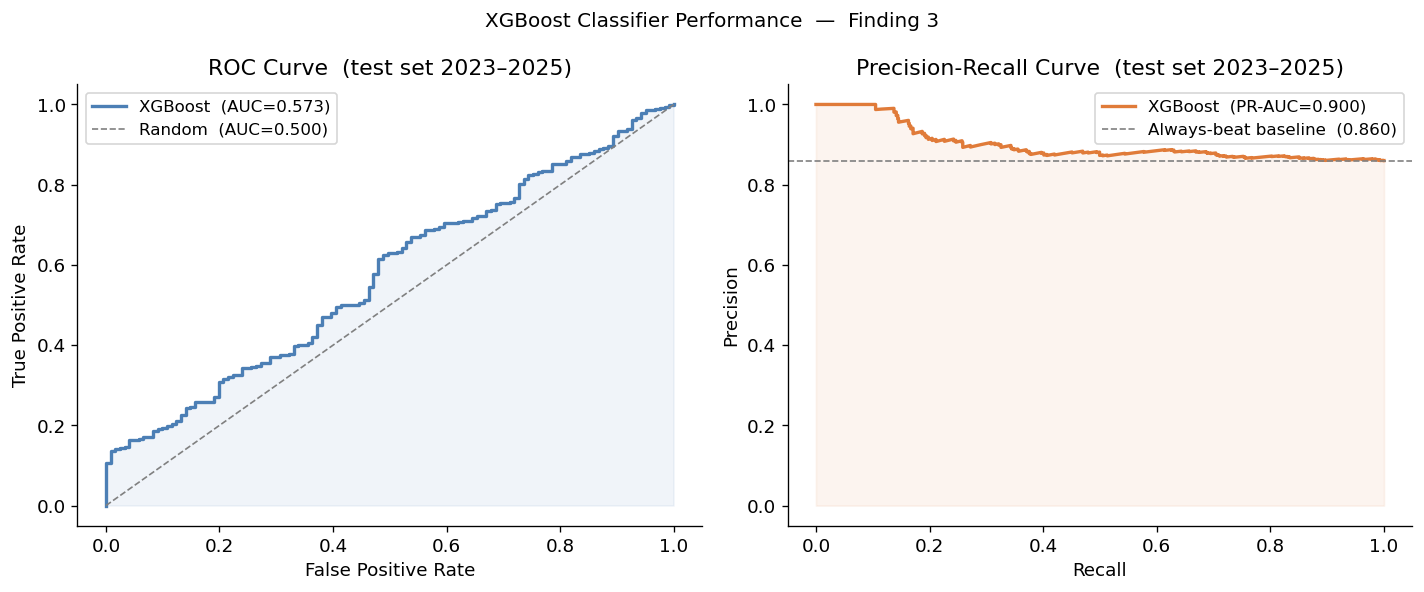

In [12]:
y_true  = results_df["beat"]
y_proba = results_df["beat_proba"]

fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc     = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_true, y_proba)
pr_auc    = average_precision_score(y_true, y_proba)
baseline  = y_true.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, color="#4c7fb5", linewidth=2,
             label=f"XGBoost  (AUC={roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="grey", linewidth=1,
             linestyle="--", label="Random  (AUC=0.500)")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#4c7fb5")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve  (test set 2023–2025)")
axes[0].legend(fontsize=10)

axes[1].plot(recall, precision, color="#e07b39", linewidth=2,
             label=f"XGBoost  (PR-AUC={pr_auc:.3f})")
axes[1].axhline(baseline, color="grey", linewidth=1, linestyle="--",
                label=f"Always-beat baseline  ({baseline:.3f})")
axes[1].fill_between(recall, precision, alpha=0.08, color="#e07b39")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve  (test set 2023–2025)")
axes[1].legend(fontsize=10)

fig.suptitle("XGBoost Classifier Performance  —  Finding 3", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "04_roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 2

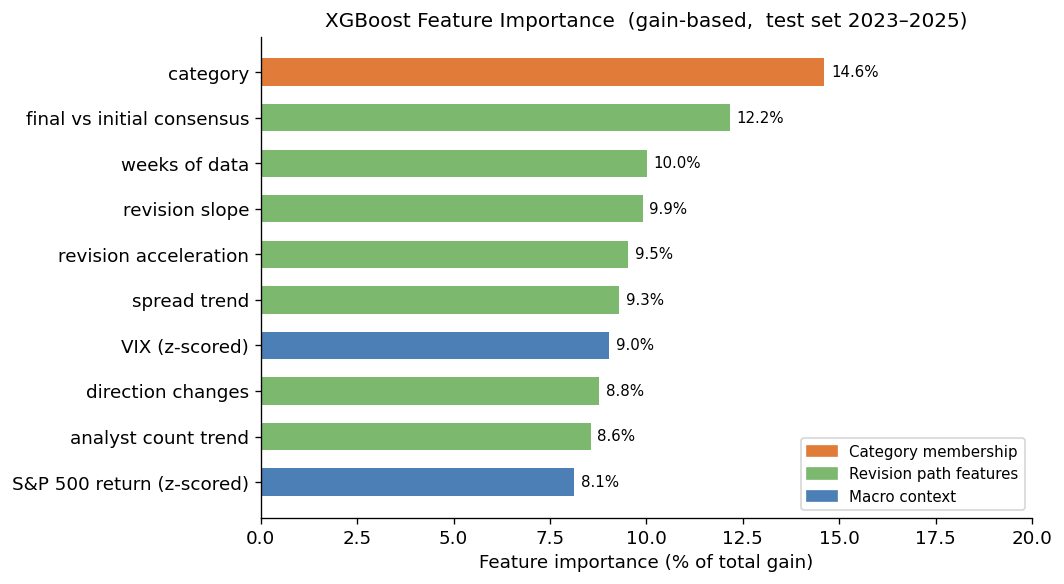

In [13]:
FEATURE_LABELS = {
    "category_encoded"    : "category",
    "final_vs_initial"    : "final vs initial consensus",
    "weeks_of_data"       : "weeks of data",
    "revision_slope"      : "revision slope",
    "revision_acceleration": "revision acceleration",
    "spread_trend"        : "spread trend",
    "vix_mean_z"          : "VIX (z-scored)",
    "direction_changes"   : "direction changes",
    "analyst_count_trend" : "analyst count trend",
    "sp500_return_z"      : "S&P 500 return (z-scored)",
}

imp_plot = imp_df.copy()
imp_plot["label"] = imp_plot["feature"].map(FEATURE_LABELS)
imp_plot = imp_plot.sort_values("gain_normalized")

colors = ["#4c7fb5" if "sp500" in f or "vix" in f
          else "#e07b39" if f == "category_encoded"
          else "#7cb86e"
          for f in imp_plot["feature"]]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(imp_plot["label"], imp_plot["gain_normalized"] * 100,
               color=colors, height=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)

patches = [
    mpatches.Patch(color="#e07b39", label="Category membership"),
    mpatches.Patch(color="#7cb86e", label="Revision path features"),
    mpatches.Patch(color="#4c7fb5", label="Macro context"),
]
ax.legend(handles=patches, fontsize=9, loc="lower right")

ax.set_xlabel("Feature importance (% of total gain)")
ax.set_title("XGBoost Feature Importance  (gain-based,  test set 2023–2025)",
             fontsize=12)
ax.set_xlim(0, 20)
plt.tight_layout()
plt.savefig(FIGURES / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3

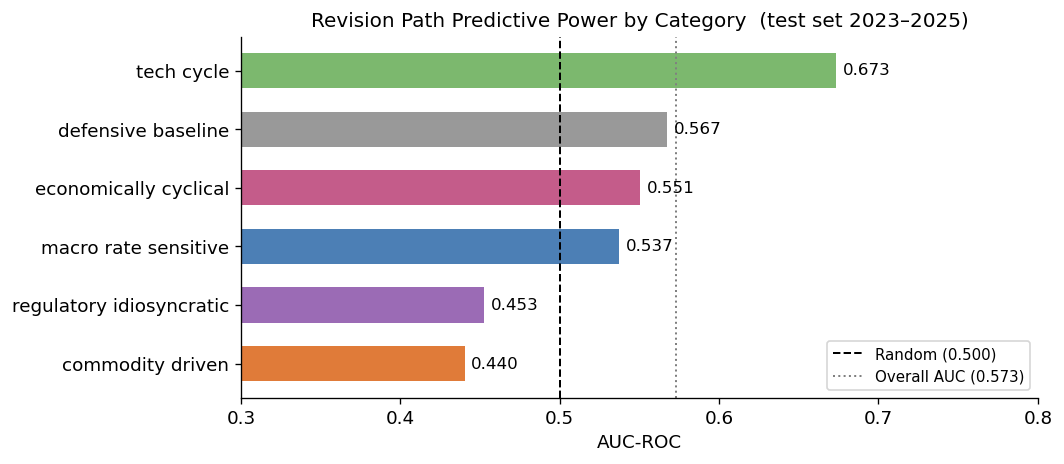

In [14]:
cat_aucs = {}
for cat in CATEGORY_ORDER:
    mask = results_df["category"] == cat
    if mask.sum() < 10:
        continue
    cat_aucs[cat] = roc_auc_score(
        results_df.loc[mask, "beat"],
        results_df.loc[mask, "beat_proba"],
    )

cat_auc_df = (
    pd.DataFrame.from_dict(cat_aucs, orient="index", columns=["auc"])
    .reindex(CATEGORY_ORDER)
    .reset_index()
    .rename(columns={"index": "category"})
    .sort_values("auc")
)

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    cat_auc_df["category"].str.replace("_", " "),
    cat_auc_df["auc"],
    color=[CAT_COLORS[c] for c in cat_auc_df["category"]],
    height=0.6,
)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
ax.axvline(0.5, color="black", linewidth=1.2, linestyle="--", label="Random (0.500)")
ax.axvline(results_df["beat"].pipe(
    lambda s: roc_auc_score(s, results_df["beat_proba"])
), color="grey", linewidth=1.2, linestyle=":",
   label=f"Overall AUC ({roc_auc_score(results_df['beat'], results_df['beat_proba']):.3f})")

ax.set_xlabel("AUC-ROC")
ax.set_title("Revision Path Predictive Power by Category  (test set 2023–2025)",
             fontsize=12)
ax.set_xlim(0.3, 0.8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "04_category_auc.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4

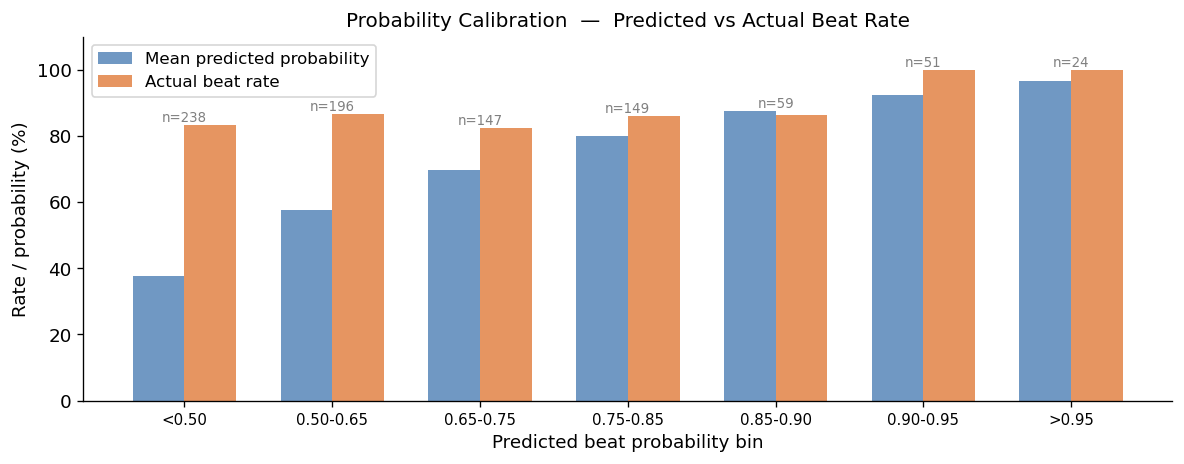

In [15]:
results_df["proba_bin"] = pd.cut(
    results_df["beat_proba"],
    bins=[0, 0.5, 0.65, 0.75, 0.85, 0.90, 0.95, 1.0],
    labels=["<0.50", "0.50-0.65", "0.65-0.75",
            "0.75-0.85", "0.85-0.90", "0.90-0.95", ">0.95"],
)

calib = (
    results_df.groupby("proba_bin", observed=True)
    .agg(
        actual_beat_rate=("beat", "mean"),
        mean_predicted=("beat_proba", "mean"),
        n=("beat", "count"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))

x = range(len(calib))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], calib["mean_predicted"] * 100,
               width=width, color="#4c7fb5", alpha=0.8, label="Mean predicted probability")
bars2 = ax.bar([i + width/2 for i in x], calib["actual_beat_rate"] * 100,
               width=width, color="#e07b39", alpha=0.8, label="Actual beat rate")

for i, row in calib.iterrows():
    ax.text(i, max(row["mean_predicted"], row["actual_beat_rate"]) * 100 + 1,
            f"n={row['n']}", ha="center", fontsize=8, color="grey")

ax.set_xticks(list(x))
ax.set_xticklabels(calib["proba_bin"].tolist(), fontsize=9)
ax.set_xlabel("Predicted beat probability bin")
ax.set_ylabel("Rate / probability (%)")
ax.set_title("Probability Calibration  —  Predicted vs Actual Beat Rate",
             fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(FIGURES / "04_calibration.png", dpi=150, bbox_inches="tight")
plt.show()